# Final Project 


<br>

---

<br>

# <span style="color:blue"> Analysis of factors contributing to student's Grade in Mathematics </span>


* **Name**:  <span style="color:blue">Koya Kashiwabara</span>
* **Student number**:  <span style="color:blue">0400377184</span>

<br>

---
## Table of contents

### 1. Overview  
### 2. Descriptive statistics  
### 3. Hypothesis testing  
### 4. Machine learning  
### 5. Summary

</br>

Note: In some descriptions, a technical note for reproducibility follows the general description.

___

# 1. Overview　　


### Purpose:


* <span>The purpose of this Final Project is to identify factors associated with students’ final grade in mathematics and to provide a real-world practice with some implications.</span>
* <span>The **key dependent variable (DV)** is **final grade(G3)**, an integer between 0 and 20. </span>
* <span> The **key independent variables (IVs)** include: </span>

1. Age       ("age" column in the CSV file)
2. Mother's education       ("Medu" column in the CSV file)
3. Father's education       ("Fedu" column in the CSV file)
4. Travel time to the school("traveltime" column in the CSV file)
5. Study time("studytime" column in the CSV file)
6. Failures  ("failures" column in the CSV file)
7. Freetime  ("freetime" column in the CSV file)
8. Going out ("goout" column in the CSV file)
9. Absences  ("absences" column in the CSV file)

</span>
* <span style="color:blue">
This dataset contains 395 cases and no missing values. This dataset originally contains 32 variables, three of which are grade point. So, this dataset also has data for 1st and 2nd grade, but I don't use them at this time since it is sure that those factors (at least seemingly) relate to the final grade.</span>

<br>

### Dataset source:

<span style="color:blue">The data come from the [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance) dataset from the [UCI Machine Learning repository](https://archive.ics.uci.edu/ml/index.php):</span>

<span style="color:blue">Analyses of this dataset have been published previously in [Cortez and Silva(2008)](https://www.semanticscholar.org/paper/61d468d5254730bbecf822c6b60d7d6595d9889c), </span>

</br>

### Reference:
Cortez, Paulo & Silva, Alice. (2008). Using data mining to predict secondary school student performance. EUROSIS. 


___

# 2. Descriptive statistics



In [1]:
import descriptive as desc

In [2]:
desc.display_summary_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Summary statistics of numerical variables.</span></p>

,age,Mother's Education,Father's education,travel,study,failures,freetime,Going out,absences,Grade
Mean,16.696,2.749,2.522,1.448,2.035,0.334,3.235,3.109,5.709,10.415
Std. Dev.,1.276,1.095,1.088,0.698,0.839,0.744,0.999,1.113,8.003,4.581
Min,15.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,0.000
Median,17.000,3.000,2.000,1.000,2.000,0.000,3.000,3.000,4.000,11.000
Max,22.000,4.000,4.000,4.000,4.000,3.000,5.000,5.000,75.000,20.000


<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

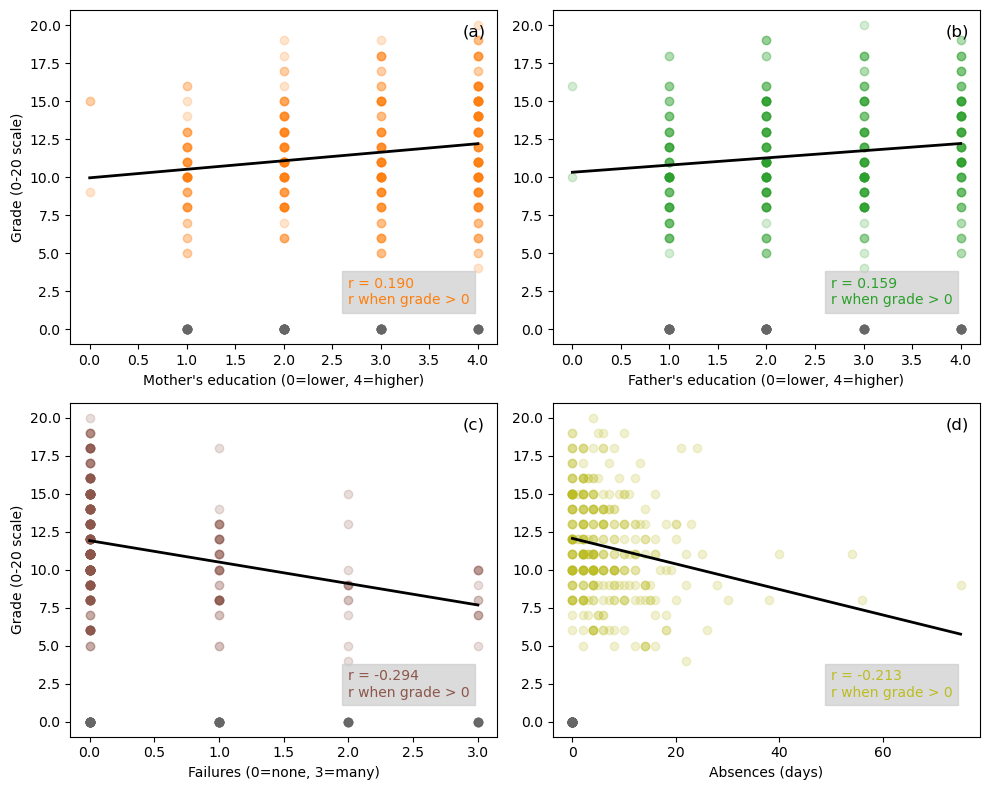

In [3]:
desc.plot_descriptive(keep=('Medu', 'Fedu', 'failures', 'absences'), num=1)

### Discussion

#### **Overview of the Data (Table 1)**  
Table 1 summarizes the central tendency and dispersion of the student grades. The mean grade is approximately **10.4** with a standard deviation of **4.58**, indicating a relatively wide variation in student performance.

#### **Key Observations (Figure 1)**  
The scatter plots and correlation coefficients, r (calculated for points whose grade > 0), suggest potential relationships between variables:  
- **Failures ($r \approx -0.29$):** A negative association suggests that past academic struggles are linked to lower current grades.  
- **Absences ($r \approx -0.21$):** A negative association suggests that absences are associated with lower performance.  
- **Medu ($r \approx 0.19$):** A moderate positive correlation implies a relationship between mother's education and student performance.  

#### **Transition to Analysis**  
While these descriptive statistics suggest that family background and past history are associated with grades, these observations describe tendencies rather than confirmed causes. The statistical significance of these patterns will be rigorously tested in **Section 3 (Hypothesis Testing)**, and their predictive power will be evaluated in **Section 4 (Machine Learning)**.

___

# 3. Hypothesis testing



In [4]:
import classical as classi

---

## Analysis 1: Impact of Student Habits
#### **Objective:**   
To examine whether Study Time, Failures, and Absences affect grades.  
  
#### **Methodology:**  
I classified students into groups based on three behavioral factors and compared their average grades using a statistical test called the t-test.

#### **Data Processing & Definitions:**
- To simplify visualization, behavioral factors were converted into binary codes.
- The way of the classification and the related variables are in  the technical note below:

#### **Technical Note:**
**Grouping Logic:**   
- `Diligence` (Study well/ Study less): Study time > 2, which is half of the scale.  
- `Experience of Failure` (Fail/ No Fail): Failures > 0.  
- `Participation` (Present/ Absent): Absences < Mean absences.

**Statistical note:**
- Multiple comparisons may inflate false positives, so results are exploratory.

<p><span style="font-size: 1.2em;"><b>Figure 2</b>: Significant pairs of groups (study time & absence & failures, p < 0.05)</span></p><br><br>

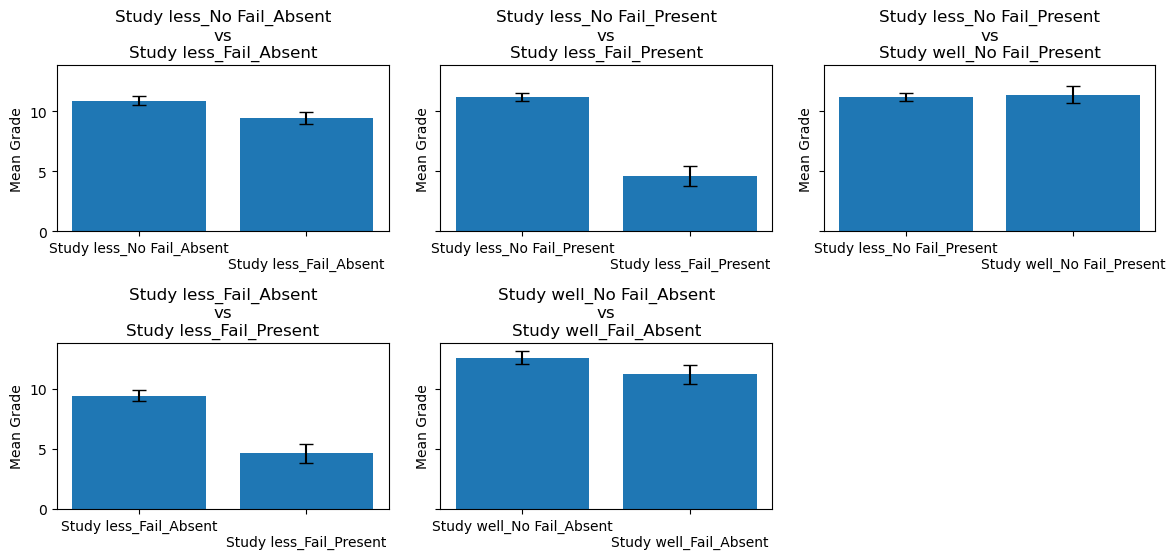

In [5]:
classi.First_analysis(num=2)

#### Discussion 1

To keep the report concise, I show only pairs where two attributes are held constant and one attribute differs, so the interpretation is cleaner. Thereby, 5 Pairs whose p-value is significant are shown.     
However, because multiple pairwise tests are conducted, results should be interpreted as exploratory.  
(Again, the "group" made from **diligence** + **experience of failure** + **participation**.)
  
So, the result, combined with the comparison of the average grades, implies that:
- failures and grade, both when students don't study much and student study much but don't participate much, are negatively related.
- Study time and grade, when students have no experience of failure and participate well, are positively related
- The experience of failure is associated with lower grades when students study well and don't participate well.

---
## Analysis 2: Impact of Family Background
#### **Objective:**  
To examine under what conditions parents' education and going out influence grades.  
  
#### **Methodology:**
We analyzed the impact of Mother's and Father's education levels and the students' social frequency as done in Analysis 1.

#### Data process and words explained

As first analysis, I classified each of mother's education, father's education, and go out into two groups. The grouping logic is shown below:  
The three letters are made of **mother's education** + **father's education** + **going out**.  


#### **Technical Note:**
* **Grouping Logic:**
    * `Mother's/Father's Education` (high medu/ low medu) (←fedu): Education Level > sample Mean.
    * `Self Control` (well ctrl/ bad ctrl): Going out frequency > sample Mean.
* **Group Labels:** same structure as Analysis 1 in order: (Mother's Education)\_(Father's Education)\_(going out). 

<p><span style="font-size: 1.2em;"><b>Figure 3</b>: Significant pairs of groups (mother/father's education & going-out, p < 0.05)</span></p><br><br>

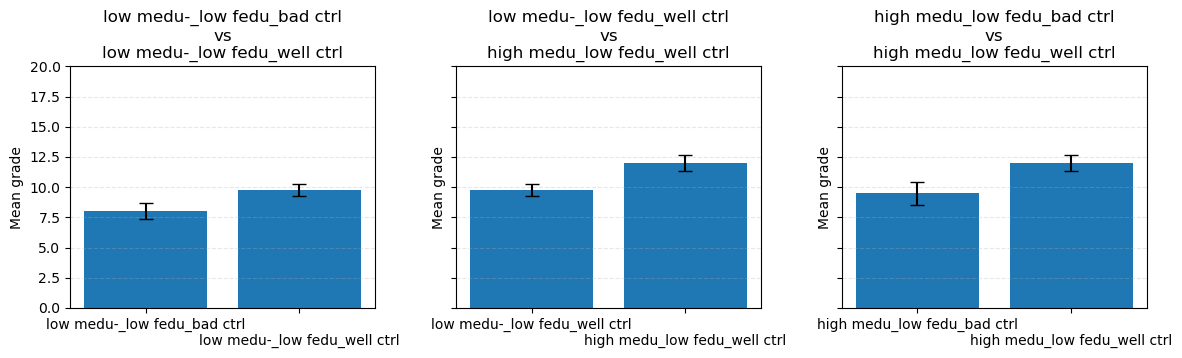

In [6]:
classi.Second_analysis(num=3)

3 Pairs whose p-value is significant, and one of whose two of the properties is identical to the other, are shown.  
However, because multiple pairwise tests are conducted, results should be interpreted as exploratory.  
(Again, the three letters are made of mother's education + father's education + going out.)
  
So, the result, combined with the comparison of the average grades, implies that:
- Less going out and grade when father's education is not so high are positively related.
- mother's education and grade, when father's education is not so high, and the student goes out less, are positively related.

___

# 4. Machine learning



In [7]:
import machine as mac


## Analysis A: Predicting Pass/Fail with Basic Factors

#### **Objective:**
To build a model to predict pass/fail outcomes and visualize the decision boundary.

#### **Methodology:**
I trained an Artificial Neural Network (ANN) classifier. Standardized features were used to improve model convergence and visualize the decision surface in 2D space.

#### **Data Processing & Definitions:**
- Target Variable: Converted final grades into binary labels (Pass: Grade ≥ 10, Fail: Grade < 10).
- Predictors: Selected Mother's Education and Absences as the two key input variables.

<p><span style="font-size: 1.2em;"><b>Figure 4</b>: Pass/ Fail Distribution in 2D: Mother’s Education vs Absences (with test set)</span></p><br><br>

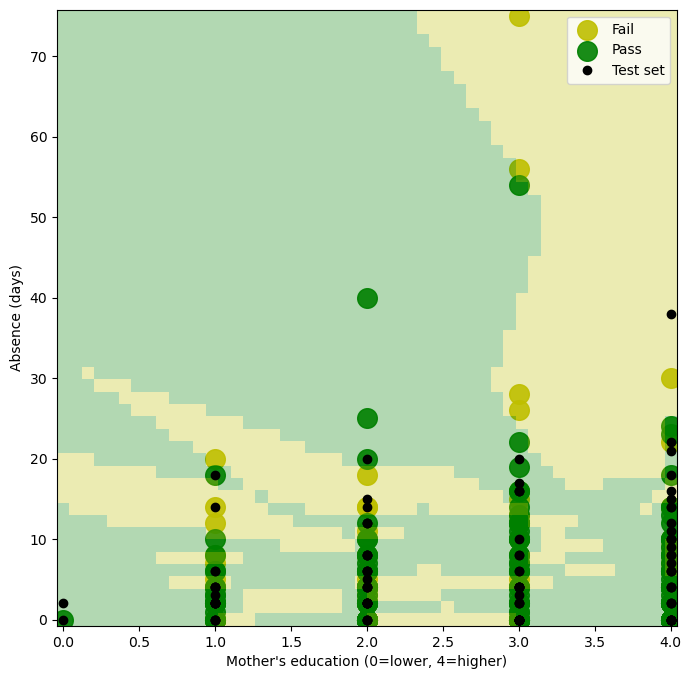

In [8]:
mac.decition_surface(num=4)

### **Interpretation:**
Based on the decision boundary and model performance:
* **Prediction Difficulty:**  
The model struggles to perfectly separate failing students from passing ones using only these two variables.
* **Still, it is a Warning Sign:**  
This model should not be used as a reliable early-warning tool, since it misses many "fail" cases. Instead, it is best interpreted as a rough risk indicator: regions where the model predicts ‘Fail’ can be treated as higher-risk and may require closer attention.

### **Technical Note:**
* **Accuracy:** Test accuracy is 0.697 (vs. baseline 0.689).
* **Recall:** Recall for "Fail" is 0.270. While low, it is non-zero, indicating the model captures some signal despite the class imbalance.

---
## Analysis B: Detecting High and Low Achievers

#### **Objective:**
To identify distinct characteristics of students with significantly high or low performance, rather than just average trends.

#### **Methodology:**
I used Decision Tree classifiers to explicitly visualize feature importance and decision rules. Models were validated using feature importance plots and test set accuracy.

#### **Data Processing & Definitions:**
- Two separate binary models were created based on grade thresholds:
- High Achievers Model: Detects students with Grade > 15.
- Low Achievers Model: Detects students with Grade < 5.

#### **Technical Note:**
- **Why this approach?:**  
Previous regression models tended to predict grades clustered around the average (5-15). To identify students at the extreme ends (who need the most attention), I switched to a classification approach targeting "High Achievers" and "Low Achievers."

<p><span style="font-size: 1.2em;"><b>Figure 5</b>: Predictors for High/ Low-Achievers</span></p><br><br>

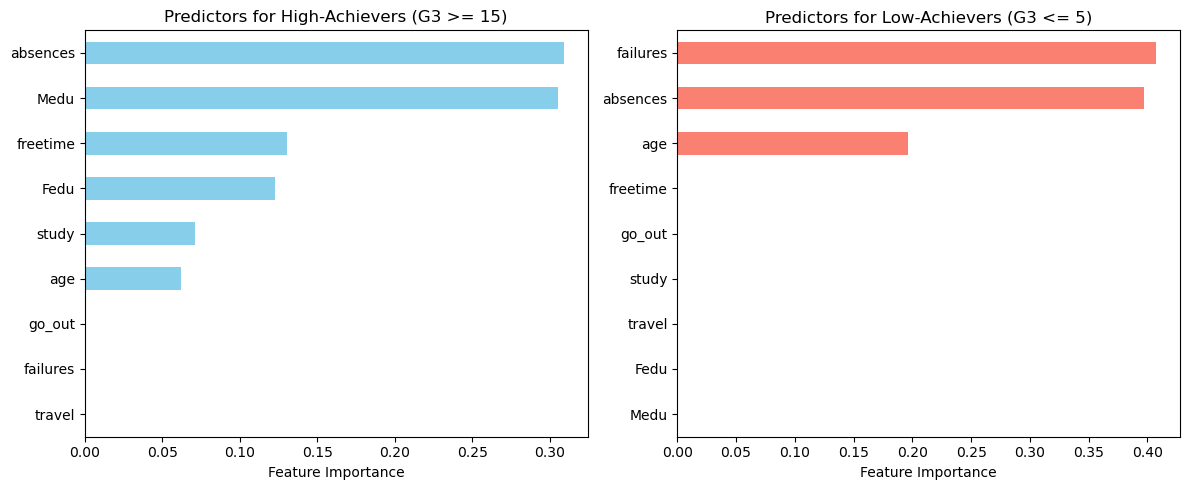

In [9]:
mac.decision_feature(num=5)

### **Interpretation:**
The analysis reveals a striking structural difference between high and low achievers, along with the impact of lifestyle and age:

1.  **High Achievers (Family Influence):**
    * Success is strongly associated with **Mother's and Father's Education**. Students from highly educated families appear to have a distinct structural advantage in achieving top grades.

2.  **Low Achievers (The Vicious Cycle):**
    * In contrast, for low achievers, family background is less significant. Instead, **Past Failures** emerge as the single most important predictor.
    * This implies a possible "vicious cycle": once a student fails, the probability of future failure increases. **Absences** are also strongly linked to this group, acting as a behavioral warning sign.

3.  **Lifestyle Matters (Actionable Factors):**
    * Beyond fixed attributes, behavioral choices might affect performance. Across both models, **fewer absences**, **less free time**, and **more study time** are consistently associated with higher scores. Unlike family background, these are actionable factors where the school can intervene.
</br>

### **Technical Note and Appendix:**
* **Model Accuracy:** Both models achieved high reliability on the test set (**High Model: 0.798**, **Low Model: 0.866**).
* **Threshold Sensitivity:** Even when widening the definition of "High/Low," the structural contrast (Family vs. Failures) remained consistent, confirming the robustness of these findings.
* **The "Age Ceiling" Effect (Additional Analysis):**
    * An additional analysis using **broader thresholds** (> 12 for high, < 8 for low) for classifying high/low scorers revealed that **Age** disappears from the *Low* model's predictors but appears at the top of the *High* model.
    * **Implication:** This implies that older age (may indicate retention) prevents students from achieving high scores, but does not determine them to the lowest scores.

___

# 5. Summary



Through statistical analysis and machine learning, this report identified the key drivers of student performance in mathematics.

## Key Findings:
1.  **The possible vicious cycle associated with prior failures:**
    * Our machine learning analysis (Figure 5) identified **past failures** as the single most important factor for low achievers.
    * This suggests that once a student fails, they are more likely to fail than others. Or, this may reflect persistent underlying difficulties rather than failures causing future failures.
2.  **The Family's education and High Achievers:**
    * High performance is strongly associated with **parents' education level** (Figure 3, Figure 5). Students from educated families seem to have an advantage.
3.  **Behavioral Warning Signs:**
    * **Absences** are a critical early warning sign. High absenteeism is an alert of low grades, more than mere lack of study time.

## Implication to the practice:
To improve overall student outcomes, the school should focus resources on **early intervention**:
* **Stop the Cycle:** Provide immediate, intensive support for students who experience their first failure to prevent the possible "vicious cycle" from starting.
* **Monitor Absences:** Treat high absenteeism as an alert for potential failure.